In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler

In [2]:
df=pd.read_csv("/home/mostafashazly/Downloads/Large-Scale Financial Fraud Dataset/improved_fraud_dataset.csv")
print(df.head())

     organization transaction_id               user_id  user_account_age_days  \
0  FinovaTech_000    TXN00000044  FinovaTech_000_U0000                   1670   
1  FinovaTech_000    TXN00000004  FinovaTech_000_U0000                   1670   
2  FinovaTech_000    TXN00000033  FinovaTech_000_U0000                   1670   
3  FinovaTech_000    TXN00000050  FinovaTech_000_U0000                   1670   
4  FinovaTech_000    TXN00000047  FinovaTech_000_U0000                   1670   

   kyc_verified payment_method card_type  transaction_amount currency  \
0             1          bkash     debit             1553.81      BDT   
1             1          bkash     debit              136.49      BDT   
2             1           card    credit             3432.40      BDT   
3             1          bkash    credit              503.59      BDT   
4             0           bank    credit             1908.35      BDT   

   fee_amount  ... device_type operating_system browser merchant_category 

In [3]:
print(df.columns.to_list())

['organization', 'transaction_id', 'user_id', 'user_account_age_days', 'kyc_verified', 'payment_method', 'card_type', 'transaction_amount', 'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week', 'city', 'country', 'device_type', 'operating_system', 'browser', 'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour', 'is_night', 'time_diff']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  str    
 1   transaction_id         1000000 non-null  str    
 2   user_id                1000000 non-null  str    
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  str    
 6   card_type              1000000 non-null  str    
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  str    
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  str    
 11  day_of_week            1000000 non-null  str    
 12  city                   1000000 non-null  str    
 13  country                1000000 non-null  str    
 14  device_type            1000000

In [5]:
fraud_rate = df["is_fraud"].mean()
print(fraud_rate)


0.09171


In [6]:
accounts_not_verified = df[(df['kyc_verified']==0)  & (df['is_fraud']== 1)& (df['otp_used'] == 0)]
print(accounts_not_verified)

          organization transaction_id               user_id  \
190     FinovaTech_000    TXN00000196  FinovaTech_000_U0003   
353     FinovaTech_000    TXN00000367  FinovaTech_000_U0007   
588     FinovaTech_000    TXN00000551  FinovaTech_000_U0011   
616     FinovaTech_000    TXN00000625  FinovaTech_000_U0012   
621     FinovaTech_000    TXN00000636  FinovaTech_000_U0012   
...                ...            ...                   ...   
999310  FinovaTech_199    TXN00999315  FinovaTech_199_U0086   
999570  FinovaTech_199    TXN00999586  FinovaTech_199_U0091   
999810  FinovaTech_199    TXN00999829  FinovaTech_199_U0096   
999821  FinovaTech_199    TXN00999827  FinovaTech_199_U0096   
999850  FinovaTech_199    TXN00999860  FinovaTech_199_U0097   

        user_account_age_days  kyc_verified payment_method card_type  \
190                       187             0          bkash    credit   
353                        34             0          bkash    credit   
588                      11

In [7]:

number_of_duplicats = accounts_not_verified.duplicated().sum()
number_of_missing_values = accounts_not_verified.isna().sum()
print(f"number_of_duplicats is: {number_of_duplicats}\n")
print(f"number_of_missing_values is: {number_of_missing_values}")

number_of_duplicats is: 0

number_of_missing_values is: organization             0
transaction_id           0
user_id                  0
user_account_age_days    0
kyc_verified             0
payment_method           0
card_type                0
transaction_amount       0
currency                 0
fee_amount               0
transaction_timestamp    0
day_of_week              0
city                     0
country                  0
device_type              0
operating_system         0
browser                  0
merchant_category        0
transaction_type         0
otp_used                 0
is_fraud                 0
hour                     0
is_night                 0
time_diff                0
dtype: int64


<Axes: >

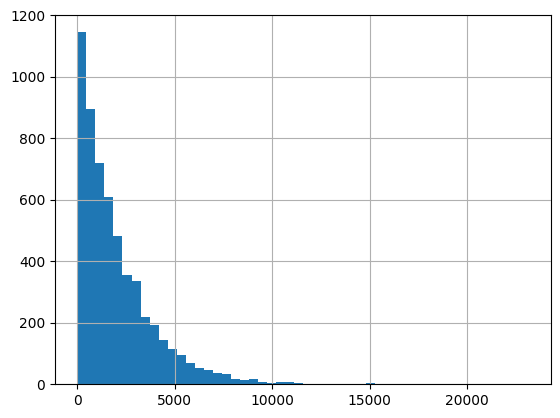

In [8]:
accounts_not_verified['transaction_amount'].mean()
accounts_not_verified['transaction_amount'].hist(bins=50)

In [9]:
accounts_not_verified['transaction_amount'].nlargest(10)

200944    23154.39
192873    17657.30
788979    17410.96
280996    17249.32
116451    16016.37
653428    15957.14
151377    15726.68
133250    15427.95
180865    15169.26
245406    15100.40
Name: transaction_amount, dtype: float64

In [10]:
print("Fraud Mean:", accounts_not_verified['transaction_amount'].mean())

normal_ops = df[df['is_fraud'] == 0]
print("Normal Mean:", normal_ops['transaction_amount'].mean())

Fraud Mean: 1998.8218333333334
Normal Mean: 2001.396133536646


In [11]:
fraud_by_os = accounts_not_verified['operating_system'].value_counts()
print(fraud_by_os)

operating_system
iOS        1899
Windows    1883
Android    1858
Name: count, dtype: int64


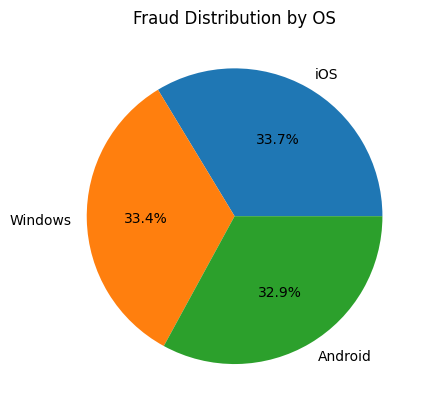

In [12]:
fraud_by_os.plot(kind='pie', autopct='%1.1f%%')
plt.title("Fraud Distribution by OS")
plt.show()

In [13]:
print(df.groupby('browser')['is_fraud'].mean(),"\n")
print(df.groupby('card_type')['is_fraud'].mean(),"\n")
print(df.groupby('currency')['is_fraud'].mean(),"\n")
print(df.groupby('merchant_category')['is_fraud'].mean(),"\n")
print(df.groupby('device_type')['is_fraud'].mean(),"\n")



browser
Chrome    0.091917
Edge      0.091536
Safari    0.091678
Name: is_fraud, dtype: float64 

card_type
credit    0.091503
debit     0.091916
Name: is_fraud, dtype: float64 

currency
BDT    0.09171
Name: is_fraud, dtype: float64 

merchant_category
electronics    0.090059
fashion        0.092329
grocery        0.092143
travel         0.092311
Name: is_fraud, dtype: float64 

device_type
desktop    0.091681
mobile     0.091516
tablet     0.091934
Name: is_fraud, dtype: float64 



In [14]:
print(df.groupby('transaction_type')['is_fraud'].mean(),"\n")
print(df.groupby('is_night')['is_fraud'].mean(),"\n")
print(df.groupby('payment_method')['is_fraud'].mean(),"\n")

transaction_type
purchase      0.091576
transfer      0.091688
withdrawal    0.091867
Name: is_fraud, dtype: float64 

is_night
0    0.006105
1    0.299754
Name: is_fraud, dtype: float64 

payment_method
bank     0.091190
bkash    0.091986
card     0.092270
nagad    0.091394
Name: is_fraud, dtype: float64 



In [15]:
print(df.groupby('currency')['is_fraud'].mean(),"\n")
print(df.groupby('country')['is_fraud'].mean(),"\n")
print(df.groupby('city')['is_fraud'].mean(),"\n")
print(df.groupby('time_diff')['is_fraud'].mean(),"\n")

currency
BDT    0.09171
Name: is_fraud, dtype: float64 

country
Bangladesh    0.09171
Name: is_fraud, dtype: float64 

city
Chittagong    0.092141
Dhaka         0.091575
Khulna        0.091091
Rajshahi      0.092032
Name: is_fraud, dtype: float64 

time_diff
0.0           0.297850
2.0           1.000000
3.0           0.333333
4.0           0.000000
6.0           0.000000
                ...   
14120645.0    0.000000
14370376.0    0.000000
14641465.0    0.000000
14736916.0    0.000000
17661552.0    0.000000
Name: is_fraud, Length: 817408, dtype: float64 



In [16]:
col_drop = [
    'currency', 'country', 'city',           
    'browser', 'device_type', 'card_type',  
    'transaction_id', 'user_id', 'organization',
    'transaction_timestamp'                            
]

df_clean = df.drop(columns=col_drop)
print(df_clean.head())

   user_account_age_days  kyc_verified payment_method  transaction_amount  \
0                   1670             1          bkash             1553.81   
1                   1670             1          bkash              136.49   
2                   1670             1           card             3432.40   
3                   1670             1          bkash              503.59   
4                   1670             0           bank             1908.35   

   fee_amount day_of_week operating_system merchant_category transaction_type  \
0       31.08      Friday          Windows           fashion         purchase   
1        2.73    Thursday          Android           grocery       withdrawal   
2       68.65    Saturday              iOS       electronics         transfer   
3       10.07    Thursday          Windows           fashion         purchase   
4       38.17     Tuesday          Windows           grocery         transfer   

   otp_used  is_fraud  hour  is_night  time_diff  

In [17]:
df_final = pd.get_dummies(df_clean)

print(df_final.head())


   user_account_age_days  kyc_verified  transaction_amount  fee_amount  \
0                   1670             1             1553.81       31.08   
1                   1670             1              136.49        2.73   
2                   1670             1             3432.40       68.65   
3                   1670             1              503.59       10.07   
4                   1670             0             1908.35       38.17   

   otp_used  is_fraud  hour  is_night  time_diff  payment_method_bank  ...  \
0         1         0     8         0        0.0                False  ...   
1         0         0     6         0  1719608.0                False  ...   
2         1         0    19         0   827250.0                False  ...   
3         1         0    19         0  1035744.0                False  ...   
4         1         0    12         0   408465.0                 True  ...   

   operating_system_Android  operating_system_Windows  operating_system_iOS  \
0      

In [18]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [19]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_final), columns=df_final.columns)
print(df_scaled.head())

   user_account_age_days  kyc_verified  transaction_amount  fee_amount  \
0               0.834171           1.0            0.049988    0.049994   
1               0.834171           1.0            0.004391    0.004391   
2               0.834171           1.0            0.110424    0.110427   
3               0.834171           1.0            0.016201    0.016198   
4               0.834171           0.0            0.061394    0.061398   

   otp_used  is_fraud      hour  is_night  time_diff  payment_method_bank  \
0       1.0       0.0  0.347826       0.0   0.000000                  0.0   
1       0.0       0.0  0.260870       0.0   0.097364                  0.0   
2       1.0       0.0  0.826087       0.0   0.046839                  0.0   
3       1.0       0.0  0.826087       0.0   0.058644                  0.0   
4       1.0       0.0  0.521739       0.0   0.023127                  1.0   

   ...  operating_system_Android  operating_system_Windows  \
0  ...                       0

In [20]:
df_scaled.to_csv("fraud_final_preprocessed.csv", index=False)
